In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("Book1.csv")
df.drop(["Revenue","Profit"], axis= 1, inplace= True)
df

,Quantity,Price,Total Cost,Order Date,Month,Customer Name,Region,Order Time (IST)
0,1,43.17,30.6507,10-Feb-2024,February,Customer 12,Central,01:44 PM
1,12,81.16,788.8752,02-Jun-2023,June,Customer 3244,North,07:41 PM
2,14,28.37,333.6312,03-Oct-2023,October,Customer 1463,East,11:49 AM
3,17,20.76,314.0988,03-May-2023,May,Customer 1223,North,01:09 PM
4,5,39.42,139.9410,18-Feb-2023,February,Customer 2248,South,12:17 PM
...,...,...,...,...,...,...,...,...
9995,16,16.05,159.2160,27-Aug-2024,August,Customer 2603,North,04:54 PM
9996,2,93.34,115.7416,26-Sep-2023,September,Customer 1309,South,01:11 PM
9997,5,37.87,136.3320,05-Jul-2023,July,Customer 3784,West,04:05 PM
9998,17,51.18,591.6408,08-Jun-2024,June,Customer 2141,Central,09:35 PM


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Revenue"] = df["Quantity"] * df["Price"]
df["Profit"] = df["Revenue"] -  df["Total Cost"] 
df["Profit Margine %"] = (df["Profit"] / df["Revenue"]) *100
df

,Quantity,Price,Total Cost,Order Date,Month,Customer Name,Region,Order Time (IST),Revenue,Profit,Profit Margine %
0,1,43.17,30.6507,2024-02-10,February,Customer 12,Central,01:44 PM,43.17,12.5193,29.0
1,12,81.16,788.8752,2023-06-02,June,Customer 3244,North,07:41 PM,973.92,185.0448,19.0
2,14,28.37,333.6312,2023-10-03,October,Customer 1463,East,11:49 AM,397.18,63.5488,16.0
3,17,20.76,314.0988,2023-05-03,May,Customer 1223,North,01:09 PM,352.92,38.8212,11.0
4,5,39.42,139.9410,2023-02-18,February,Customer 2248,South,12:17 PM,197.10,57.1590,29.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,16,16.05,159.2160,2024-08-27,August,Customer 2603,North,04:54 PM,256.80,97.5840,38.0
9996,2,93.34,115.7416,2023-09-26,September,Customer 1309,South,01:11 PM,186.68,70.9384,38.0
9997,5,37.87,136.3320,2023-07-05,July,Customer 3784,West,04:05 PM,189.35,53.0180,28.0
9998,17,51.18,591.6408,2024-06-08,June,Customer 2141,Central,09:35 PM,870.06,278.4192,32.0


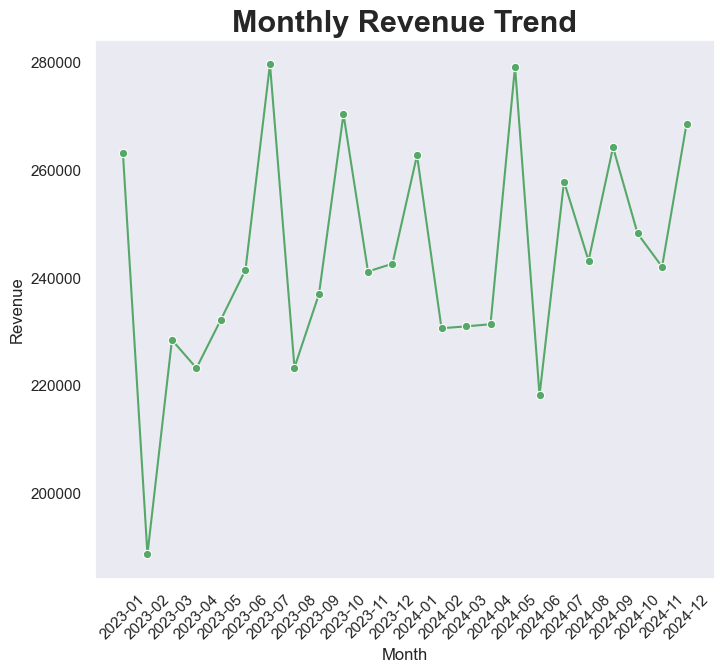

In [6]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly = df.groupby("Month")["Revenue"].sum().reset_index()
monthly["Month"] = monthly["Month"].astype(str)

sns.set(style = "dark")
plt.figure(figsize = (8,7))
sns.lineplot(data = monthly, x = "Month", y = "Revenue",color = "g" ,marker = "o")
plt.title("Monthly Revenue Trend", fontsize = 22, fontweight = "bold")
plt.xticks(rotation = 45)
plt.show()

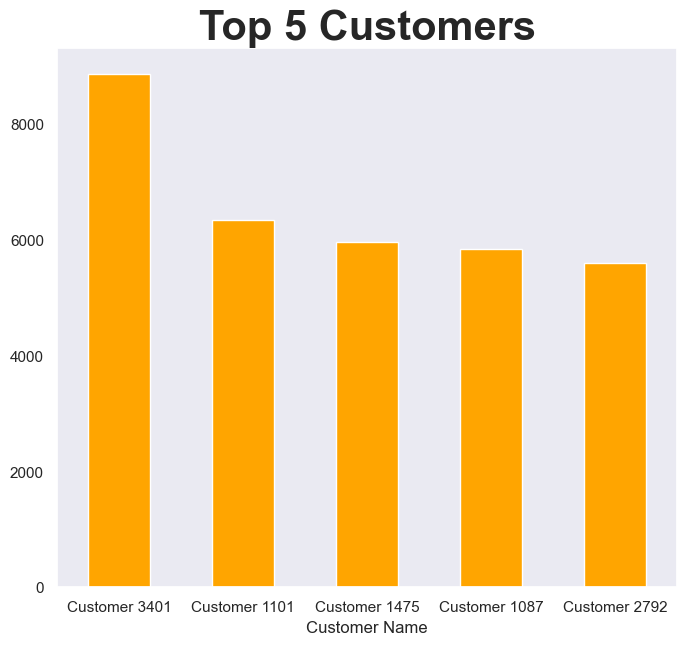

In [12]:
Top_Customer = (df.groupby("Customer Name")["Revenue"].sum().sort_values(ascending= False).head(5))
plt.figure(figsize = (8,7))
Top_Customer.plot(kind = "bar", color = "orange")
plt.title("Top 5 Customers", fontsize = 30, fontweight = "bold")
plt.xticks(rotation = 360)
plt.show()

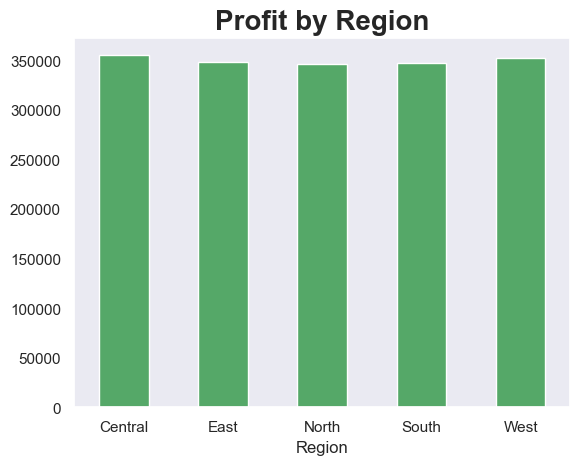

In [13]:
Profit_Region = (df.groupby("Region")["Profit"].sum())

Profit_Region.plot(kind = "bar", color = "g")
plt.title("Profit by Region", fontsize = 20, fontweight = "bold")
plt.xticks(rotation = 360)
plt.show()

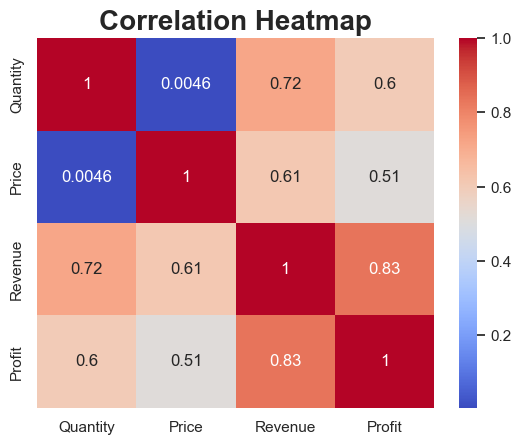

In [14]:
sns.heatmap(df[["Quantity","Price","Revenue","Profit"]].corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap", fontsize = 20, fontweight = "bold")
plt.show()

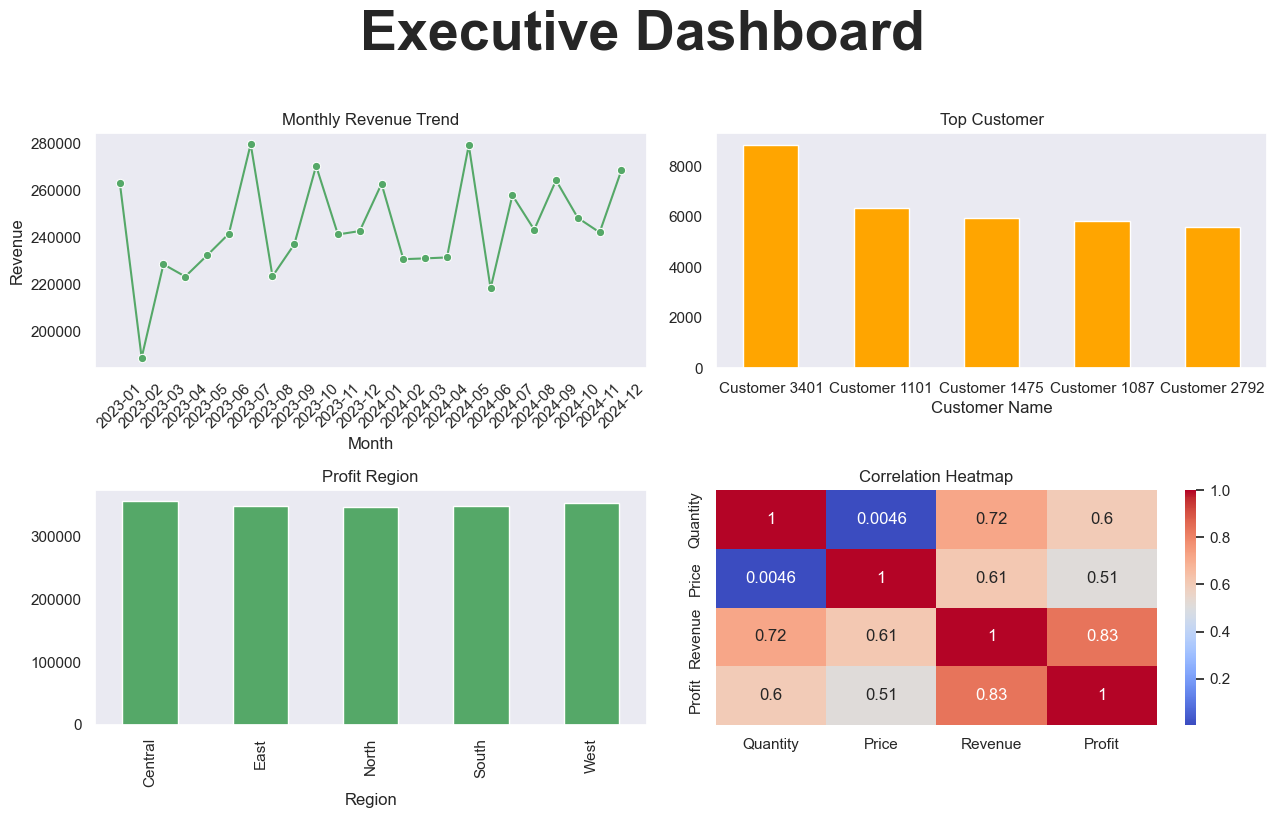

In [15]:
fig, axs = plt.subplots(2,2, figsize = (13,8))

sns.lineplot(data = monthly, x = "Month", y = "Revenue",color = "g" ,marker = "o", ax = axs[0,0])
axs[0,0].set_title("Monthly Revenue Trend")
axs[0,0].tick_params(axis = "x", rotation = 45)

Top_Customer.plot(kind = "bar", color = "orange", ax = axs[0,1])
axs[0,1].set_title("Top Customer")
axs[0,1].tick_params(axis = "x", rotation = 360)

Profit_Region.plot(kind = "bar", color = "g",ax =axs[1,0])
axs[1,0].set_title("Profit Region")

sns.heatmap(df[["Quantity","Price","Revenue","Profit"]].corr(), annot = True, cmap = "coolwarm",
            ax = axs[1,1])
axs[1,1].set_title("Correlation Heatmap")

fig.suptitle("Executive Dashboard", fontsize = 40, fontweight = "bold", y = 1.02)
plt.tight_layout()
plt.show()